# Tidy3D: LN Rib Waveguide Mode + Fiber Overlap (1550 nm)

This notebook:
1. Builds a **Lithium Niobate (LN) rib waveguide** on a **10 µm SiO₂ underclad** (straight waveguide length = **100 µm** for geometry visualization).
2. Solves the **fundamental eigenmode** on the **xy cross-section** (z-invariant).
3. Plots **|Ex| and |Ey|** zoomed to **x,y ∈ [-2, 2] µm**.
4. Builds a **Gaussian fiber mode** (flat-cleaved SMF) with **MFD = 10.4 µm** and computes **amplitude overlap** and **power overlap**.

> Notes:
> - This uses an **isotropic** LN refractive index `n_ln = 2.20` as a starting point. LN is anisotropic; if you know cut/orientation and TE/TM, you can upgrade to `td.AnisotropicMedium`.
> - Mode solving is performed via `tidy3d.plugins.mode.ModeSolver` on an xy plane.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tidy3d as td
from tidy3d.plugins.mode import ModeSolver

21:14:25 Eastern Standard Time ERROR: Failed to apply Tidy3D plotting style on  
                               import. Error: 'tidy3d.style' not found in the   
                               style library and input is not a valid URL or    
                               path; see `style.available` for list of available
                               styles                                           

## Parameters

In [2]:
# ----------------------------
# 1) Wavelength / frequency
# ----------------------------
lambda0_um = 1.55
freq0 = td.C_0 / lambda0_um

# ----------------------------
# 2) Materials
# ----------------------------
# SiO2 from Tidy3D material library
sio2 = td.material_library["SiO2"]["Horiba"]

# Lithium Niobate (LN) - isotropic approximation (upgrade to anisotropic if needed)
n_ln = 2.20
ln = td.Medium(permittivity=n_ln**2)

# Top cladding: air
air = td.Medium(permittivity=1.0)

# ----------------------------
# 3) Geometry dimensions (µm)
# ----------------------------
t_ln = 0.300          # LN total thickness
t_slab = 0.100        # slab thickness
t_rib = t_ln - t_slab # rib height above slab

w_rib = 0.800         # rib top width
w_slab = 5.600        # slab/mesa width (your: 7*0.8 = 5.6 µm)

t_sio2 = 10.0         # SiO2 underclad thickness
Lz = 100.0            # straight waveguide length (for geometry visualization)

# ----------------------------
# 4) Simulation domain sizes (µm)
# ----------------------------
sx = 20.0             # x span
air_above = 6.0       # air above LN
sy = t_sio2 + air_above  # total y span
cy = (air_above - t_sio2) / 2.0  # y-center so bottom is -t_sio2 and top is +air_above

print(f"Rib height above slab: {t_rib:.3f} µm (etch depth {t_rib:.3f} µm, slab remaining {t_slab:.3f} µm)")

Rib height above slab: 0.200 µm (etch depth 0.200 µm, slab remaining 0.100 µm)


## Build Geometry (3D for visualization + 2.5D for mode solving)

21:14:28 Eastern Standard Time WARNING: Structure at 'structures[0]' has bounds 
                               that extend exactly to simulation edges. This can
                               cause unexpected behavior. If intending to extend
                               the structure to infinity along one dimension,   
                               use td.inf as a size variable instead to make    
                               this explicit.                                   

                               WARNING: Suppressed 8 WARNING messages.          

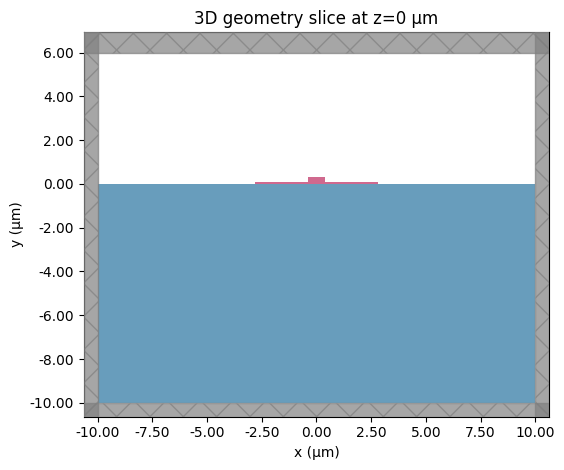

In [3]:
# ----------------------------
# 5) Structures for mode solve (z-invariant)
# ----------------------------
substrate = td.Structure(
    geometry=td.Box(center=(0.0, -t_sio2/2.0, 0.0), size=(sx, t_sio2, td.inf)),
    medium=sio2,
)

ln_slab = td.Structure(
    geometry=td.Box(center=(0.0, t_slab/2.0, 0.0), size=(w_slab, t_slab, td.inf)),
    medium=ln,
)

ln_rib = td.Structure(
    geometry=td.Box(center=(0.0, t_slab + t_rib/2.0, 0.0), size=(w_rib, t_rib, td.inf)),
    medium=ln,
)

structures_mode = [substrate, ln_slab, ln_rib]

# ----------------------------
# 6) 3D straight waveguide geometry (finite length = 100 µm) for visualization
# ----------------------------
substrate_3d = td.Structure(
    geometry=td.Box(center=(0.0, -t_sio2/2.0, 0.0), size=(sx, t_sio2, Lz)),
    medium=sio2,
)
ln_slab_3d = td.Structure(
    geometry=td.Box(center=(0.0, t_slab/2.0, 0.0), size=(w_slab, t_slab, Lz)),
    medium=ln,
)
ln_rib_3d = td.Structure(
    geometry=td.Box(center=(0.0, t_slab + t_rib/2.0, 0.0), size=(w_rib, t_rib, Lz)),
    medium=ln,
)

sim_3d_geom_only = td.Simulation(
    center=(0.0, cy, 0.0),
    size=(sx, sy, Lz),
    grid_spec=td.GridSpec.auto(min_steps_per_wvl=20, wavelength=lambda0_um),
    structures=[substrate_3d, ln_slab_3d, ln_rib_3d],
    run_time=1e-12,
    medium=air,
    boundary_spec=td.BoundarySpec.all_sides(td.PML()),
)

ax = sim_3d_geom_only.plot(z=0.0)
plt.title("3D geometry slice at z=0 µm")
plt.show()

## Mode Solve (xy cross-section)

In [5]:
# ----------------------------
# 7) Mode-solver simulation (2.5D)
# ----------------------------
sim_mode = td.Simulation(
    center=(0.0, cy, 0.0),
    size=(sx, sy, 1.0),
    grid_spec=td.GridSpec.auto(min_steps_per_wvl=25, wavelength=lambda0_um),
    structures=structures_mode,
    run_time=1e-12,
    medium=air,
)

plane = td.Box(center=(0.0, cy, 0.0), size=(sx, sy, 0.0))

mode_spec = td.ModeSpec(
    num_modes=1,
    target_neff=2.1,  # starting guess; adjust if you don't find the intended mode
)

mode_solver = ModeSolver(
    simulation=sim_mode,
    plane=plane,
    mode_spec=mode_spec,
    freqs=[freq0],
)

mode_data = mode_solver.solve()

print("Solved modes:", mode_data.n_eff)
print("neff:", mode_data.n_eff.values)

21:18:31 Eastern Standard Time WARNING: Structure at 'structures[0]' has bounds 
                               that extend exactly to simulation edges. This can
                               cause unexpected behavior. If intending to extend
                               the structure to infinity along one dimension,   
                               use td.inf as a size variable instead to make    
                               this explicit.                                   

                               WARNING: Suppressed 2 WARNING messages.          

Solved modes: <xarray.ModeIndexDataArray (f: 1, mode_index: 1)> Size: 8B
array([[1.6383355]])
Coordinates:
  * f           (f) float64 8B 1.934e+14
  * mode_index  (mode_index) int32 4B 0
Attributes:
    long_name:  Propagation index
neff: [[1.6383355]]


## Plot |Ex| and |Ey| (zoom to x,y ∈ [-2, 2] µm)

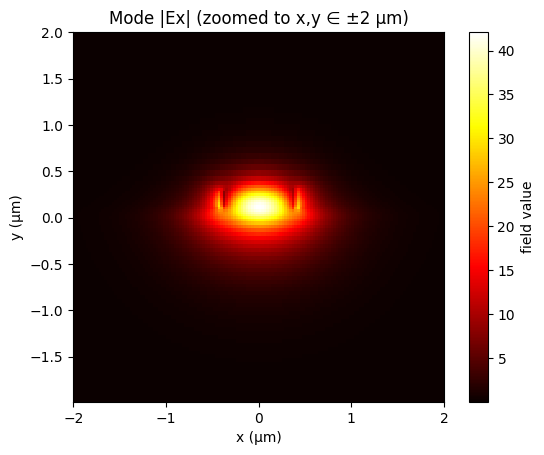

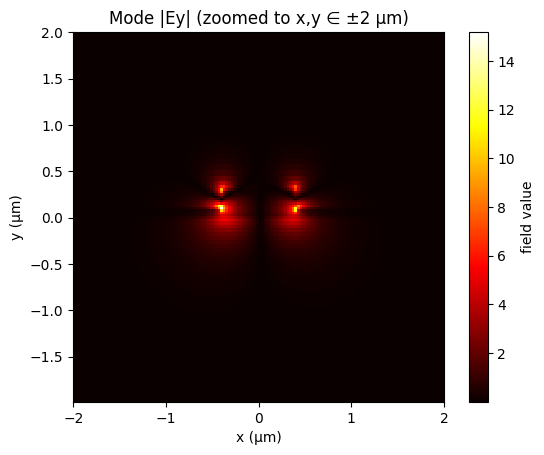

In [6]:
# ----------------------------
# 8) Mode visualization (zoomed)
# ----------------------------
xlim = (-2.0, 2.0)
ylim = (-2.0, 2.0)

Ex_zoom = mode_data.Ex.abs.sel(x=slice(*xlim), y=slice(*ylim))
Ey_zoom = mode_data.Ey.abs.sel(x=slice(*xlim), y=slice(*ylim))

Ex_zoom.plot(x="x", y="y", cmap="hot")
plt.title("Mode |Ex| (zoomed to x,y ∈ ±2 µm)")
plt.gca().set_aspect("equal")
plt.xlabel("x (µm)")
plt.ylabel("y (µm)")
plt.show()

Ey_zoom.plot(x="x", y="y", cmap="hot")
plt.title("Mode |Ey| (zoomed to x,y ∈ ±2 µm)")
plt.gca().set_aspect("equal")
plt.xlabel("x (µm)")
plt.ylabel("y (µm)")
plt.show()

## Fiber Gaussian Mode + Overlap (MFD = 10.4 µm)

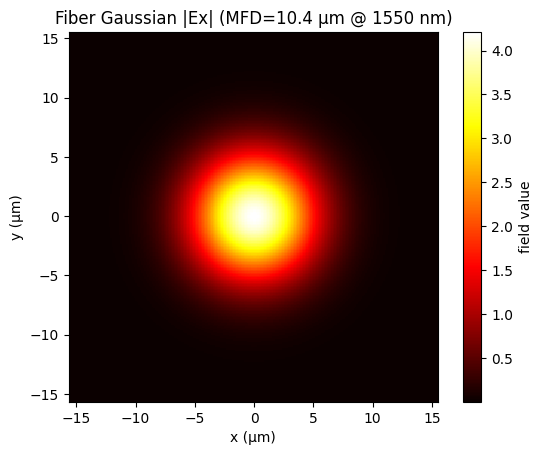

Amplitude overlap = (0.19973166275690582-5.3134132811126066e-05j)
Power overlap (coupling efficiency) = 0.039893
Coupling loss = -13.99 dB
Shifted power overlap (dx=0.0 µm, dy=0.0 µm) = 0.039893 (-13.99 dB)


In [9]:
# ----------------------------
# 9) Fiber mode (Gaussian) and overlap
# ----------------------------
MFD_um = 10.4
w0_um = MFD_um / 2.0  # 1/e^2 intensity radius

beam_plane_size = 6 * w0_um  # generous window to include tails

# Choose pol_angle to match the dominant polarization of your guided mode
# pol_angle = pi/2 -> Ey polarization; pol_angle = 0 -> Ex polarization
gaussian_beam = td.GaussianBeamProfile(
    waist_radius=w0_um,
    pol_angle=0,
    size=(beam_plane_size, beam_plane_size, 0.0),
    resolution=250,
    freqs=[freq0],
)

# Optional: visualize fiber Gaussian field in the same xy plane
gaussian_beam.field_data.Ex.abs.plot(x="x", y="y", cmap="hot")
plt.title("Fiber Gaussian |Ex| (MFD=10.4 µm @ 1550 nm)")
plt.gca().set_aspect("equal")
plt.xlabel("x (µm)")
plt.ylabel("y (µm)")
plt.show()

# Amplitude overlap (complex); power overlap = |overlap|^2
overlap_amp = mode_data.outer_dot(gaussian_beam.field_data).values.squeeze()
power_overlap = np.abs(overlap_amp) ** 2

print(f"Amplitude overlap = {overlap_amp}")
print(f"Power overlap (coupling efficiency) = {power_overlap:.6f}")
print(f"Coupling loss = {10*np.log10(power_overlap):.2f} dB")

# Misalignment sweep example (single offset):
dx_um, dy_um = 0.0, 0.0
mode_shifted = mode_data.translated_copy(vector=(dx_um, dy_um, 0.0))
overlap_amp_shifted = mode_shifted.outer_dot(gaussian_beam.field_data).values.squeeze()
power_overlap_shifted = np.abs(overlap_amp_shifted) ** 2
print(f"Shifted power overlap (dx={dx_um} µm, dy={dy_um} µm) = {power_overlap_shifted:.6f} "
      f"({10*np.log10(power_overlap_shifted):.2f} dB)")

In [15]:
import numpy as np

# Sweep parameters (µm)
y_start = -5
y_stop  = 5.00
y_step  = 0.010  # 10 nm

ys = np.arange(y_start, y_stop + 10*y_step, y_step)

power_overlaps = []
amp_overlaps = []

# IMPORTANT:
# We shift the Gaussian beam in +y by shifting the waveguide mode in -y.
# (This is just relative alignment; either direction is fine as long as you're consistent.)
for y0 in ys:
    md_shift = mode_data.translated_copy(vector=(0.0, -y0, 0.0))  # waveguide down => fiber effectively up
    a = md_shift.outer_dot(gaussian_beam.field_data).values.squeeze()
    eta = np.abs(a)**2
    amp_overlaps.append(a)
    power_overlaps.append(eta)

power_overlaps = np.array(power_overlaps)

# Find best
i_best = int(np.argmax(power_overlaps))
y_best = float(ys[i_best])
eta_best = float(power_overlaps[i_best])

print(f"Best vertical alignment y = {y_best:.3f} µm")
print(f"Max power overlap = {eta_best:.6f}  ({10*np.log10(eta_best):.2f} dB)")

# Print table (y, overlap)
print("\n y (µm)    power_overlap")
for y0, eta in zip(ys, power_overlaps):
    print(f"{y0:7.3f}    {eta:.8f}")


Best vertical alignment y = -0.020 µm
Max power overlap = 0.039894  (-13.99 dB)

 y (µm)    power_overlap
 -5.000    0.00650122
 -4.990    0.00654873
 -4.980    0.00659642
 -4.970    0.00664435
 -4.960    0.00669258
 -4.950    0.00674106
 -4.940    0.00678982
 -4.930    0.00683876
 -4.920    0.00688796
 -4.910    0.00693745
 -4.900    0.00698716
 -4.890    0.00703718
 -4.880    0.00708739
 -4.870    0.00713791
 -4.860    0.00718867
 -4.850    0.00723962
 -4.840    0.00729087
 -4.830    0.00734241
 -4.820    0.00739421
 -4.810    0.00744625
 -4.800    0.00749847
 -4.790    0.00755103
 -4.780    0.00760382
 -4.770    0.00765688
 -4.760    0.00771019
 -4.750    0.00776375
 -4.740    0.00781761
 -4.730    0.00787168
 -4.720    0.00792598
 -4.710    0.00798060
 -4.700    0.00803547
 -4.690    0.00809063
 -4.680    0.00814599
 -4.670    0.00820159
 -4.660    0.00825751
 -4.650    0.00831364
 -4.640    0.00837009
 -4.630    0.00842675
 -4.620    0.00848370
 -4.610    0.00854091
 -4.600    0.0

In [13]:
a_self = mode_data.outer_dot(mode_data).values.squeeze()
print(a_self, abs(a_self)**2)

(1.0000000000000002-3.943807064060934e-23j) 1.0000000000000004
